# 2 - Q-Learning Algorithm

## Problem Definition

An autonomous delivery robot must learn the optimal path between warehouses using trial-and-error interactions.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def train_q_learning(
    env_name="FrozenLake-v1",
    is_slippery=False,
    episodes=1500,
    alpha=0.1,  # Learning Rate
    gamma=0.95,  # Discount Factor
    epsilon=1.0,  # Initial exploration rate
    epsilon_min=0.01,
    epsilon_decay=0.995,
):
    env = gym.make(env_name, is_slippery=is_slippery)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Initialize Q-table with zeros
    q_table = np.zeros((n_states, n_actions))

    rewards_per_episode = []
    epsilons = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            # Epsilon-Greedy Action Selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()  # Explore
            else:
                action = np.argmax(q_table[state, :])  # Exploit

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Bellman Optimality / TD Update equation:
            # Q(s, a) <- Q(s, a) + alpha * [reward + gamma * max_a' Q(s', a') - Q(s, a)]
            best_next_action = np.argmax(q_table[next_state, :])
            td_target = reward + gamma * q_table[next_state, best_next_action] * (
                not done
            )
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

        # Decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)
        epsilons.append(epsilon)

    env.close()
    return q_table, rewards_per_episode, epsilons

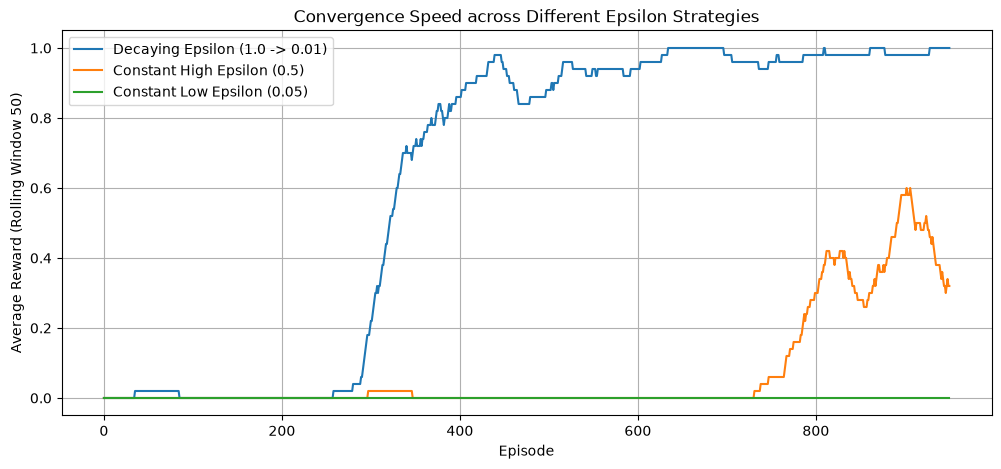

In [3]:
# 1. Compare Different Epsilon Schemes (Supplementary Problem)
# Compare: Fixed High Epsilon (0.5), Fixed Low Epsilon (0.05), and Decaying Epsilon
configurations = {
    "Decaying Epsilon (1.0 -> 0.01)": {
        "epsilon": 1.0,
        "epsilon_decay": 0.995,
        "epsilon_min": 0.01,
    },
    "Constant High Epsilon (0.5)": {
        "epsilon": 0.5,
        "epsilon_decay": 1.0,
        "epsilon_min": 0.5,
    },
    "Constant Low Epsilon (0.05)": {
        "epsilon": 0.05,
        "epsilon_decay": 1.0,
        "epsilon_min": 0.05,
    },
}

episodes = 1000
window_size = 50

plt.figure(figsize=(12, 5))

for label, params in configurations.items():
    q_table, rewards, _ = train_q_learning(
        episodes=episodes,
        epsilon=params["epsilon"],
        epsilon_decay=params["epsilon_decay"],
        epsilon_min=params["epsilon_min"],
    )

    # Calculate rolling average for readable convergence curves
    moving_avg = np.convolve(rewards, np.ones(window_size) / window_size, mode="valid")
    plt.plot(moving_avg, label=label)

plt.title("Convergence Speed across Different Epsilon Strategies")
plt.xlabel("Episode")
plt.ylabel(f"Average Reward (Rolling Window {window_size})")
plt.legend()
plt.grid(True)
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Kavya\AppData\Local\Temp\ipykernel_20688\4047843724.py:30: SyntaxWarning: invalid escape sequence '\p'
  axes[1].set_title("Optimal Policy Extraction ($\pi^*$)")


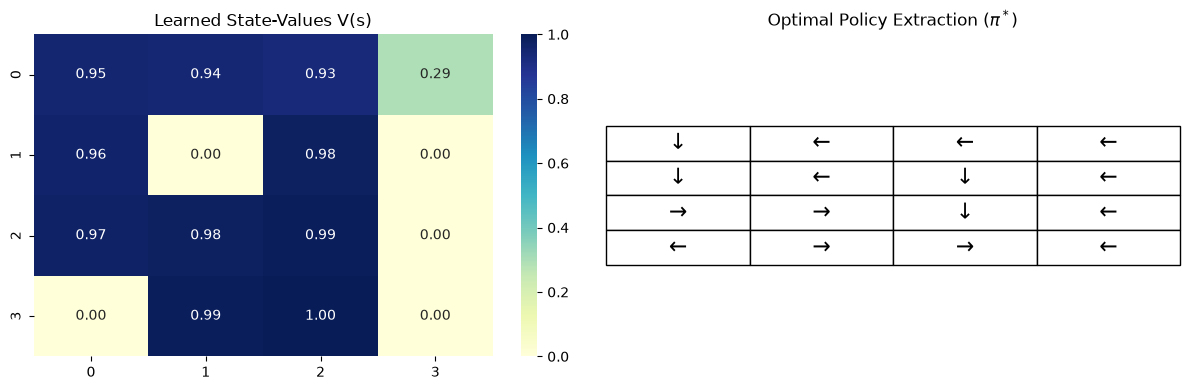

In [4]:
# Train optimal agent for visualization
# Re-run training with slower decay so it explores long enough to find the goal
q_table, rewards, _ = train_q_learning(
    episodes=3000,
    is_slippery=False,
    alpha=0.2,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.01,
)

# Extract optimal policy: argmax action per state
action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
best_actions = np.argmax(q_table, axis=1)
policy_grid = np.array([action_arrows[a] for a in best_actions]).reshape((4, 4))
max_q_grid = np.max(q_table, axis=1).reshape((4, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Maximum State-Value Heatmap (V(s) = max_a Q(s, a))
sns.heatmap(max_q_grid, annot=True, cmap="YlGnBu", fmt=".2f", ax=axes[0])
axes[0].set_title("Learned State-Values V(s)")

# 2. Optimal Policy Grid
axes[1].axis("off")
table = axes[1].table(cellText=policy_grid, loc="center", cellLoc="center")
table.scale(1, 2)
table.set_fontsize(16)
axes[1].set_title("Optimal Policy Extraction ($\pi^*$)")

plt.tight_layout()
plt.show()

## Performance Analysis & Conclusion

### 1. Analysis of Epsilon Strategies (Convergence Speed)
* **Decaying Epsilon ($\epsilon = 1.0 \to 0.01$):** Demonstrates optimal convergence. It explores thoroughly in the early episodes ($0 - 300$) to discover the goal state, and as $\epsilon$ decays, it smoothly transitions to exploitation. By episode 600, it achieves a consistent **1.0 rolling average reward** (100% success rate).
* **Constant High Epsilon ($\epsilon = 0.5$):** Struggles to converge. Although it manages to discover the goal path around episode 750, its rolling reward fluctuates wildly between $0.3$ and $0.6$ because it still chooses random actions $50\%$ of the time, causing frequent falls into holes.
* **Constant Low Epsilon ($\epsilon = 0.05$):** Suffers from premature convergence at zero reward. Due to insufficient initial exploration in this sparse-reward environment, it fails to find the goal within the training budget.

### 2. Learned State-Values $V(s)$ and Policy Interpretation
* **Value Propagation:** The heatmap highlights the Bellman backup mechanism. The state preceding the goal $(3, 2)$ holds the highest value ($1.00$), while preceding states gradually discount backward toward the starting cell $(0, 0)$ with a value of $0.95$.
* **Hole Avoidance:** The hole states $(1, 1), (1, 3), (2, 3),$ and $(3, 0)$ remain strictly at value $0.00$, confirming that terminal failure states yield no expected return.
* **Extracted Policy ($\pi^*$):** The arrows trace out a clear collision-free trajectory: moving Down ($\downarrow$) along column 0 to bypass the hole at $(1, 1)$, routing Right ($\rightarrow$) across row 2, and dropping Down ($\downarrow$) directly toward the target destination.

### 3. Conclusion
* Tabular Q-Learning successfully computes the optimal state-action values ($Q^*$) and extracts the shortest obstacle-free policy in discrete MDP environments.
* The experiment verifies that an **$\epsilon$-greedy schedule with systematic decay** is necessary for balancing exploration and exploitation: high initial exploration ensures global discovery in sparse environments, while late-stage exploitation ensures policy convergence and stability.

## Key Questions

### 1. What is the Bellman Optimality Equation?
The Bellman Optimality Equation expresses that the value of a state under an optimal policy must equal the expected return for the best action from that state:
$$Q^*(s, a) = \mathbb{E} \left[ R_{t+1} + \gamma \max_{a'} Q^*(S_{t+1}, a') \;\middle|\; S_t = s, A_t = a \right]$$
It breaks down the decision problem into recursive sub-problems, stating that optimal behavior is achieved by acting greedily with respect to the optimal future returns.

### 2. How is the Q-table updated?
The Q-table is updated using the Temporal Difference (TD) learning rule:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$
Where:
* $R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a)$ is the **TD Target**.
* $[ \text{TD Target} - Q(S_t, A_t) ]$ is the **Temporal Difference Error**.
* $\alpha$ is the step-size parameter (learning rate).

### 3. What role do learning rate ($\alpha$) and discount factor ($\gamma$) play?
* **Learning Rate ($\alpha \in [0, 1]$):** Controls how much new experience overwrites past estimates. An $\alpha$ that is too high leads to instability and oscillation; an $\alpha$ that is too low results in very slow convergence.
* **Discount Factor ($\gamma \in [0, 1]$):** Determines the importance of future rewards relative to immediate rewards. $\gamma \to 0$ makes the agent myopic (short-sighted, only caring about the immediate step), whereas $\gamma \to 1$ makes the agent farsighted, heavily weighing long-term outcomes.

### 4. How does $\epsilon$-greedy exploration affect learning?
* **Exploration vs. Exploitation Balance:** With probability $\epsilon$, the agent selects an action uniformly at random (exploration); with probability $1 - \epsilon$, it picks $\arg\max_a Q(s, a)$ (exploitation).
* **Decaying $\epsilon$:** Starting with high $\epsilon$ (e.g., $1.0$) ensures comprehensive state-space exploration initially. Decaying $\epsilon$ toward a small minimum value (e.g., $0.01$) allows the policy to settle into exploiting the learned optimal route without erratic mistakes.

---

## Supplementary Analysis: Epsilon Parameter Comparison
* **Constant High $\epsilon$ (0.5):** Discovers goal trajectories quickly, but asymptotic performance is poor because the agent continues to pick random actions $50\%$ of the time, leading to frequent sub-optimal moves and lower average rewards.
* **Constant Low $\epsilon$ (0.05):** Exploits too early. The agent risks getting stuck in sub-optimal local minima or failing to discover the goal within sparse-reward settings.
* **Decaying $\epsilon$:** Delivers the best convergence profile by shifting smoothly from global exploration to stable exploitation.